In [1]:
import utils.file as futils
import utils.data as datutils
import utils.score as score
import utils.corrs as corrs
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import warnings
from pandas.errors import ParserWarning

warnings.simplefilter(action='ignore', category=ParserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['axes.labelsize'] = 18
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"
plt.style.use('tableau-colorblind10')
colors = [
    '#000000',      # Black
    '#0072B2',      # Blue
    '#009E73',      # Bluish Green
    '#F0E442',      # Yellow
    '#CC79A7',      # Reddish Purple
    '#D55E00',      # Vermilion
    '#56B4E9',      # Sky Blue
    '#E69F00'       # Orange
]

In [2]:
def plot_split(axs, mah_25, mah_50, mah_75, l25, u25, time, indx):
    axs.set_xlabel('Scale Factor a = 1/(1+z)')
    axs.set_ylabel('m(a)')

    for i, mah in enumerate(mah_25):
        if i == 0:
            axs.plot(time, mah,
                    color='blue', alpha=0.3, lw=1, label='lower 25%')
        else:
            axs.plot(time, mah,
                    color='blue', alpha=0.3, lw=1)

    for i, mah in enumerate(mah_75):
        if i == 0:
            axs.plot(time, mah,
                    color='red', alpha=0.3, lw=1, label='upper 25%')
        else:
            axs.plot(time, mah,
                    color='red', alpha=0.3, lw=1)
            
    # axs.plot(
    #     time, mah_50[0],
    #     color='green', lw=3, label='median'
    # )


    # Lower 25%
    axs.plot(
        time, l25[1],
        color='blue', lw=3, label='lower 25% (median)'
    )
    # fill between 16th and 84th percentiles
    axs.fill_between(   
        time, l25[0], l25[2],
        color='blue', alpha=0.25, linewidth=0
    )

    # Upper 25%
    axs.plot(
        time, u25[1],
        color='red', lw=3, label='upper 25% (median)'
    )
    # fill between 16th and 84th percentiles
    axs.fill_between(
        time, u25[0], u25[2],
        color='red', alpha=0.25, linewidth=0
    )

    axs.vlines(time[indx], ymin=-1, ymax=1.5, color='k', ls='--')
    axs.set_ylim(0.0, 1.01)
    axs.legend()

In [4]:
# Load data
mah_dict = futils.get_mah_all()
ma, common_aexp = datutils.interp_ma(mah_dict)
am, common_mass = datutils.get_am(ma=ma, scales=common_aexp,
                                  min_mass_bin=0.01, log_spacing=True)
# for nans in am, want to use previous value
# but if first value is nan, set to 0 and propagate till we get a non-nan value
am[:, 0] = np.nan_to_num(am[:, 0], nan=0.0)
am = np.fmax.accumulate(am, axis=1)
dsdf = futils.get_ds()
dsdf.drop(columns=['eta_500[8]',
                   'delta_500[9]', 'fm_500[10]', 'fm2_500[11]'], inplace=True)
dsdf = dsdf.loc[mah_dict.keys()]
dsdf.reset_index(inplace=True)
dsdf.set_index('ID', inplace=True)
m14 = pd.read_csv('data/gadgetx3k/mag_diff_GadgetX_3k.csv')
m14.set_index('ID', inplace=True)
m14 = m14.loc[mah_dict.keys()]
m14.reset_index(inplace=True)
m14.set_index('ID', inplace=True)
sm_df_zx = futils.get_morphologies(
    'results/zx/rin50.0kpc_rout1.0Mpc_205.csv')
sm_df_xy = futils.get_morphologies(
    'results/xy/rin50.0kpc_rout1.0Mpc_205.csv')
sm_df_yz = futils.get_morphologies(
    'results/yz/rin50.0kpc_rout1.0Mpc_205.csv')
smdf = pd.concat([sm_df_xy, sm_df_yz, sm_df_zx])

df1 = futils.get_morphologies('results/xy/r_0.03Mpc_205.csv')
df2 = futils.get_morphologies('results/yz/r_0.03Mpc_205.csv')
df3 = futils.get_morphologies('results/zx/r_0.03Mpc_205.csv')

stacked_inner_df = pd.concat([df1, df2, df3])

stacked_iconc = stacked_inner_df['C']

iconc = df3['C']
iconc.name = 'core_C'

/Users/kabelo/clusters/utils/data.py:290: RuntimeWarning: invalid value encountered in log
  np.log(_m_peaks), np.log(_scales), bounds_error=False, fill_value=np.nan


# Spearman Coefficients

## Morphology

In [5]:
df = pd.concat([sm_df_zx, m14['proj_z']], axis=1)

start = time.time()
ma_sm_dict, filtered_z_list = datutils.prepare_ma_corrs(
    mah_dict, df)
am_sm_dict = datutils.prepare_am_corrs(
    am, masses=common_mass, df0=df)
z_array = np.array(filtered_z_list)
aexp = 1/(1+z_array)
end = time.time()
print(f'{end-start:.1f}s')

6.3s


In [21]:
importlib.reload(score)

<module 'utils.score' from '/Users/kabelo/clusters/utils/score.py'>

In [22]:
rho = score.build_rho(df=df, mah=ma)   # corrs as function of mah
wsum_sm = score.wsum(x=df, weights=rho)  # scores as function of mah
scores, indx = score.calc_score(
    time=common_aexp, target=0.5, wsum=wsum_sm) # scores at target time, target time index
mah_25, mah_50, mah_75, l25, u25 = score.split_mah(
    mah_dict, scores) # split mah

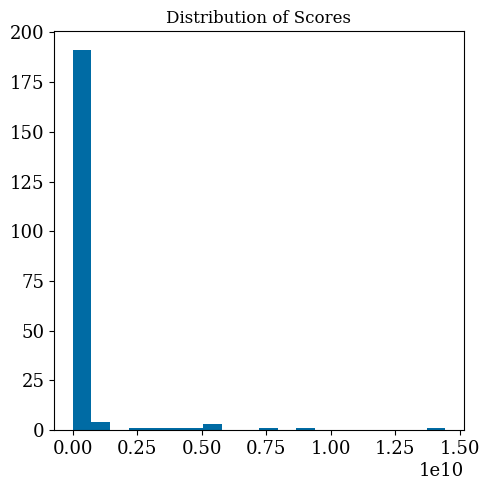

In [23]:
fig, axs = plt.subplots(1, 1, figsize=(5, 5))
axs.hist(scores, bins=20)
axs.set_title('Distribution of Scores')
plt.tight_layout()
plt.show()

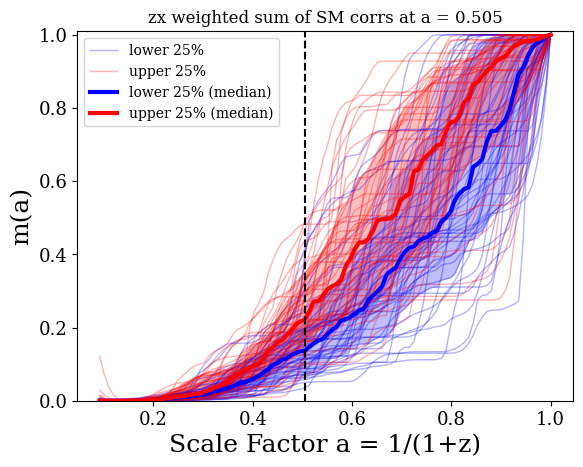

In [24]:
fig, axs = plt.subplots(1, 1)
axs.set_xlabel('Scale Factor a = 1/(1+z)')
axs.set_ylabel('m(a)')
axs.set_title(
    f'zx weighted sum of SM corrs at a = {common_aexp[indx]:.3g}')

for i, mah in enumerate(mah_25):
    if i == 0:
        axs.plot(common_aexp, mah,
                 color='blue', alpha=0.3, lw=1, label='lower 25%')
    else:
        axs.plot(common_aexp, mah,
                 color='blue', alpha=0.3, lw=1)

for i, mah in enumerate(mah_75):
    if i == 0:
        axs.plot(common_aexp, mah,
                 color='red', alpha=0.3, lw=1, label='upper 25%')
    else:
        axs.plot(common_aexp, mah,
                 color='red', alpha=0.3, lw=1)
# Lower 25%
axs.plot(
    common_aexp, l25[1],
    color='blue', lw=3, label='lower 25% (median)'
)
axs.fill_between(
    common_aexp, l25[0], l25[2],
    color='blue', alpha=0.25, linewidth=0
)

# Upper 25%
axs.plot(
    common_aexp, u25[1],
    color='red', lw=3, label='upper 25% (median)'
)
axs.fill_between(
    common_aexp, u25[0], u25[2],
    color='red', alpha=0.25, linewidth=0
)

axs.vlines(common_aexp[indx], ymin=-1, ymax=1.5, color='k', ls='--')
axs.set_ylim(0.0, 1.01)
axs.legend()
plt.show()

## Dynamical State

In [52]:
df = pd.concat([dsdf, m14['3d']], axis=1)

start = time.time()
ma_ds_dict, _ = datutils.prepare_ma_corrs(
    mah_dict, df)
am_ds_dict = datutils.prepare_am_corrs(
    am, masses=common_mass, df0=df)
end = time.time()
print(f'{end-start:.1f}s')

6.0s


In [ ]:
# corrs as function of mah
rho = score.build_rho(time=common_aexp, df=df, param_dict=ma_ds_dict)
wsum_ds = score.wsum(x=df.to_numpy(), weights=rho)  # scores as function of mah
# scores at target time, target time index
scores, indx = score.calc_score(time=common_aexp, target=0.5, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25 = score.split_mah(
    mah_dict, scores)  # split mah into lower and upper 25%

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(5, 5))
axs.hist(scores, bins=20)
axs.set_title('Distribution of Scores')
plt.tight_layout()
plt.show()

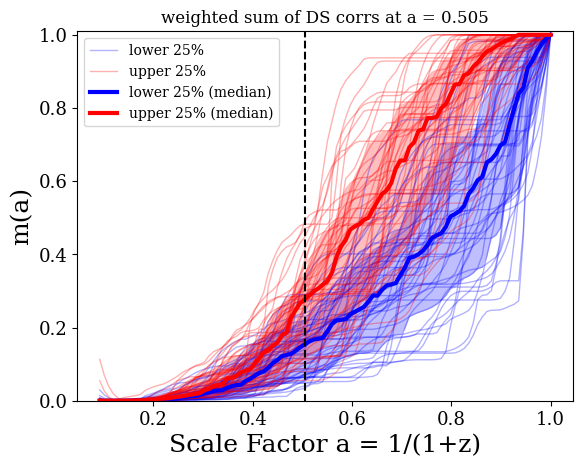

In [54]:
fig, axs = plt.subplots(1, 1)
axs.set_xlabel('Scale Factor a = 1/(1+z)')
axs.set_ylabel('m(a)')
axs.set_title(
    f'weighted sum of DS corrs at a = {common_aexp[indx]:.3g}')

for i, mah in enumerate(mah_25):
    if i == 0:
        axs.plot(common_aexp, mah,
                 color='blue', alpha=0.3, lw=1, label='lower 25%')
    else:
        axs.plot(common_aexp, mah,
                 color='blue', alpha=0.3, lw=1)

for i, mah in enumerate(mah_75):
    if i == 0:
        axs.plot(common_aexp, mah,
                 color='red', alpha=0.3, lw=1, label='upper 25%')
    else:
        axs.plot(common_aexp, mah,
                 color='red', alpha=0.3, lw=1)
# Lower 25%
axs.plot(
    common_aexp, l25[1],
    color='blue', lw=3, label='lower 25% (median)'
)
axs.fill_between(
    common_aexp, l25[0], l25[2],
    color='blue', alpha=0.25, linewidth=0
)

# Upper 25%
axs.plot(
    common_aexp, u25[1],
    color='red', lw=3, label='upper 25% (median)'
)
axs.fill_between(
    common_aexp, u25[0], u25[2],
    color='red', alpha=0.25, linewidth=0
)

axs.vlines(common_aexp[indx], ymin=-1, ymax=1.5, color='k', ls='--')
axs.set_ylim(0.0, 1.01)
axs.legend()
plt.show()

# MultiCAM Training Coefficients

## Dynamical State

In [73]:
df = pd.concat([dsdf, m14['3d']], axis=1)

start = time.time()
x = df.to_numpy()
y = ma
t, _, _, _, ds_weights = corrs.multicorr(x, y)
end = time.time()
print(f'{end - start:.1f}s')

24.4s


In [74]:
np.shape(t), np.shape(ds_weights)

((1000, 100), (100, 5))

In [61]:
wsum_ds = score.wsum(x=df, weights=ds_weights)  # scores as function of mah
# scores at target time, target time index
scores, indx = score.calc_score(time=common_aexp, target=0.7, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25 = score.split_mah(
    mah_dict, scores)  # split mah into lower and upper 25%

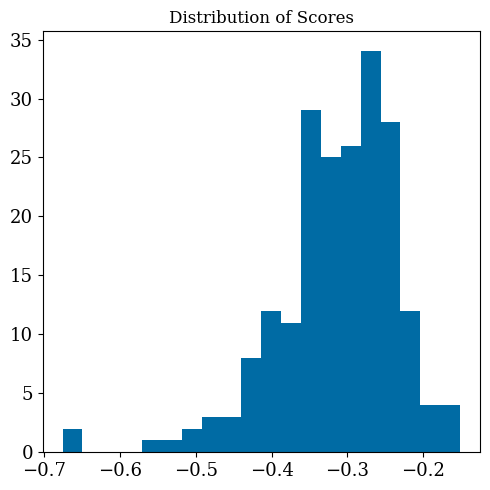

In [62]:
fig, axs = plt.subplots(1, 1, figsize=(5, 5))
axs.hist(scores, bins=20)
axs.set_title('Distribution of Scores')
plt.tight_layout()
plt.show()

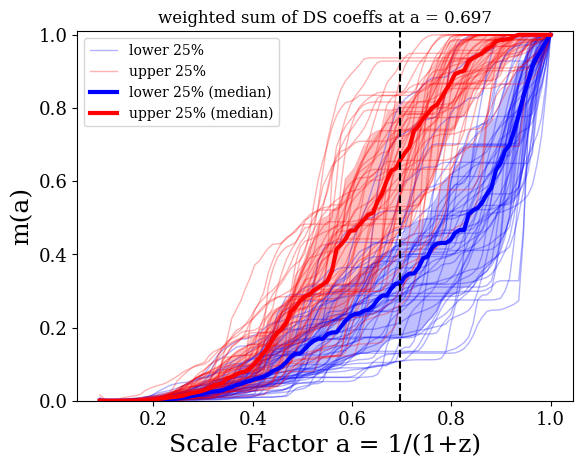

In [48]:
fig, axs = plt.subplots(1, 1)
axs.set_xlabel('Scale Factor a = 1/(1+z)')
axs.set_ylabel('m(a)')
axs.set_title(
    f'weighted sum of DS coeffs at a = {common_aexp[indx]:.3g}')

for i, mah in enumerate(mah_25):
    if i == 0:
        axs.plot(common_aexp, mah,
                 color='blue', alpha=0.3, lw=1, label='lower 25%')
    else:
        axs.plot(common_aexp, mah,
                 color='blue', alpha=0.3, lw=1)

for i, mah in enumerate(mah_75):
    if i == 0:
        axs.plot(common_aexp, mah,
                 color='red', alpha=0.3, lw=1, label='upper 25%')
    else:
        axs.plot(common_aexp, mah,
                 color='red', alpha=0.3, lw=1)
# Lower 25%
axs.plot(
    common_aexp, l25[1],
    color='blue', lw=3, label='lower 25% (median)'
)
axs.fill_between(
    common_aexp, l25[0], l25[2],
    color='blue', alpha=0.25, linewidth=0
)

# Upper 25%
axs.plot(
    common_aexp, u25[1],
    color='red', lw=3, label='upper 25% (median)'
)
axs.fill_between(
    common_aexp, u25[0], u25[2],
    color='red', alpha=0.25, linewidth=0
)

axs.vlines(common_aexp[indx], ymin=-1, ymax=1.5, color='k', ls='--')
axs.set_ylim(0.0, 1.01)
axs.legend()
plt.show()

## Morphologies

In [35]:
df = pd.concat([sm_df_zx, m14['proj_z'], iconc], axis=1)
start = time.time()
x = df.to_numpy()
y = ma
_, _, _, _, sm_weights = corrs.multicorr(x, y)
end = time.time()
print(f'{end - start:.1f}s')

21.6s


In [36]:
wsum_sm = score.wsum(x=df, weights=sm_weights)  # scores as function of mah
# scores at target time, target time index
scores, indx = score.calc_score(time=common_aexp, target=0.5, wsum=wsum_sm)
mah_25, mah_75, l25, u25 = score.split_mah(
    mah_dict, scores)  # split mah into lower and upper 25%

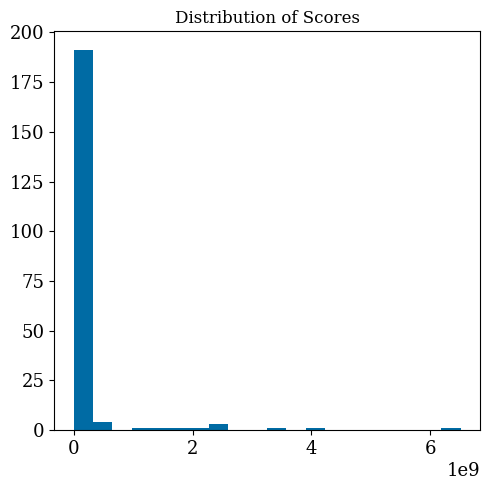

In [37]:
fig, axs = plt.subplots(1, 1, figsize=(5, 5))
axs.hist(scores, bins=20)
axs.set_title('Distribution of Scores')
plt.tight_layout()
plt.show()

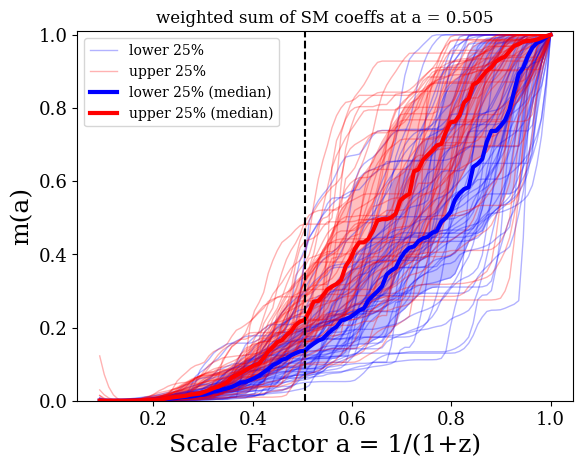

In [38]:
fig, axs = plt.subplots(1, 1)
axs.set_xlabel('Scale Factor a = 1/(1+z)')
axs.set_ylabel('m(a)')
axs.set_title(
    f'weighted sum of SM coeffs at a = {common_aexp[indx]:.3g}')

for i, mah in enumerate(mah_25):
    if i == 0:
        axs.plot(common_aexp, mah,
                 color='blue', alpha=0.3, lw=1, label='lower 25%')
    else:
        axs.plot(common_aexp, mah,
                 color='blue', alpha=0.3, lw=1)

for i, mah in enumerate(mah_75):
    if i == 0:
        axs.plot(common_aexp, mah,
                 color='red', alpha=0.3, lw=1, label='upper 25%')
    else:
        axs.plot(common_aexp, mah,
                 color='red', alpha=0.3, lw=1)
# Lower 25%
axs.plot(
    common_aexp, l25[1],
    color='blue', lw=3, label='lower 25% (median)'
)
axs.fill_between(
    common_aexp, l25[0], l25[2],
    color='blue', alpha=0.25, linewidth=0
)

# Upper 25%
axs.plot(
    common_aexp, u25[1],
    color='red', lw=3, label='upper 25% (median)'
)
axs.fill_between(
    common_aexp, u25[0], u25[2],
    color='red', alpha=0.25, linewidth=0
)

axs.vlines(common_aexp[indx], ymin=-1, ymax=1.5, color='k', ls='--')
axs.set_ylim(0.0, 1.01)
axs.legend()
plt.show()

### Stacked morphologies

# Big plot

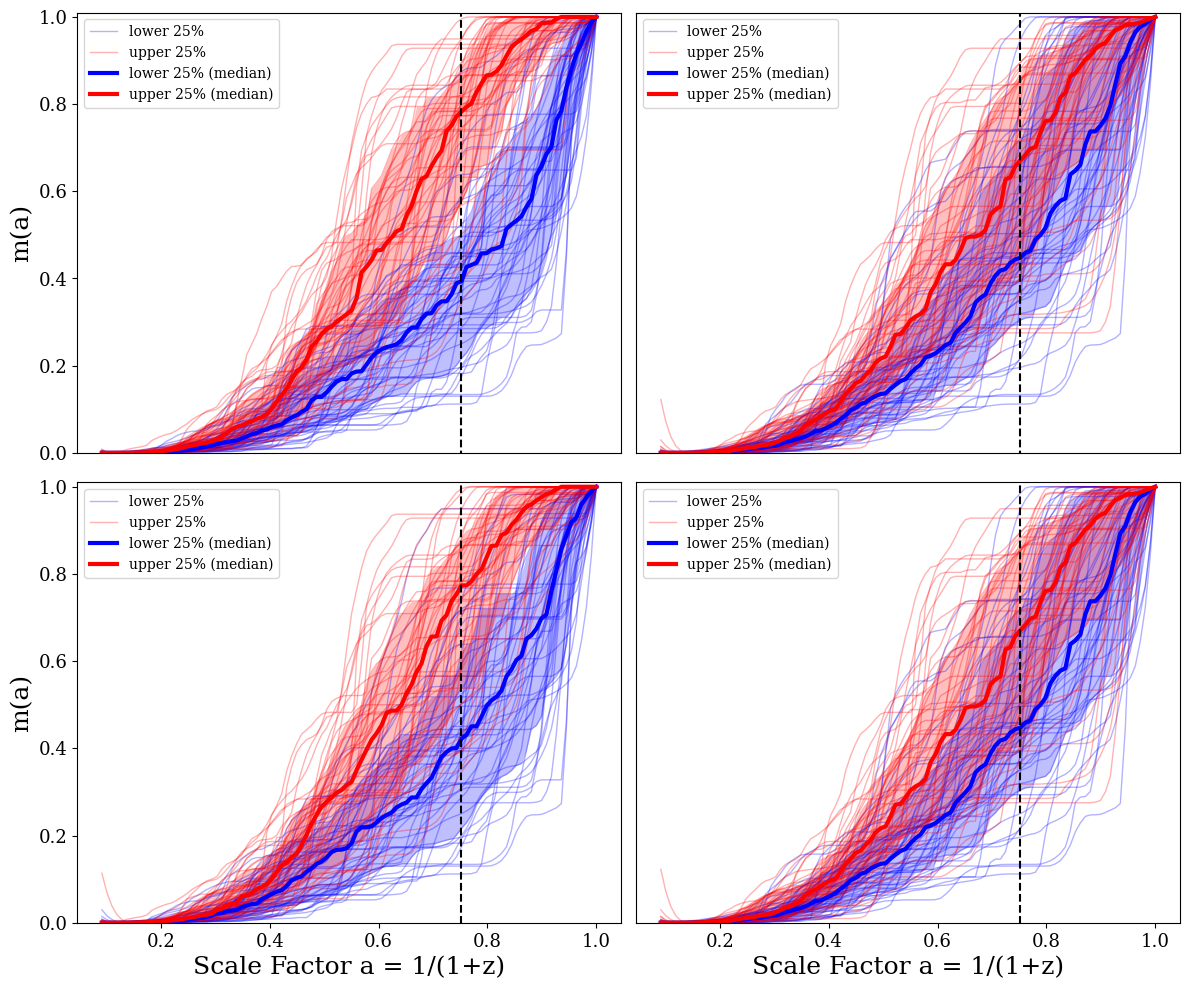

In [71]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

df = pd.concat([dsdf, m14['3d']], axis=1)
x = df.to_numpy()
y = ma
_, _, _, _, ds_weights = corrs.multicorr(x, y)
wsum_ds = score.wsum(x=df, weights=ds_weights)  # scores as function of mah
# scores at target time, target time index
scores, indx = score.calc_score(time=common_aexp, target=0.75, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25 = score.split_mah(
    mah_dict, scores)  # split mah into lower and upper 25%
plot_split(axs[0, 0], mah_25, mah_50, mah_75, l25, u25, common_aexp, indx)
axs[0, 0].xaxis.set_visible(False)

df = pd.concat([sm_df_zx, m14['proj_z'], iconc], axis=1)
x = df.to_numpy()
y = ma
_, _, _, _, sm_weights = corrs.multicorr(x, y)
wsum_sm = score.wsum(x=df, weights=sm_weights)  # scores as function of mah
# scores at target time, target time index
scores, indx = score.calc_score(time=common_aexp, target=0.75, wsum=wsum_sm)
mah_25, mah_50, mah_75, l25, u25 = score.split_mah(
    mah_dict, scores)  # split mah into lower and upper 25%
plot_split(axs[0, 1], mah_25, mah_50, mah_75, l25, u25, common_aexp, indx)
axs[0, 1].xaxis.set_visible(False)
axs[0, 1].yaxis.set_visible(False)


df = pd.concat([dsdf, m14['3d']], axis=1)
ma_ds_dict, _ = datutils.prepare_ma_corrs(
    mah_dict, df)
am_ds_dict = datutils.prepare_am_corrs(
    am, masses=common_mass, df0=df)
# corrs as function of mah
rho = score.build_rho(time=common_aexp, df=df, param_dict=ma_ds_dict)
wsum_ds = score.wsum(x=df, weights=rho)  # scores as function of mah
# scores at target time, target time index
scores, indx = score.calc_score(time=common_aexp, target=0.75, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25 = score.split_mah(
    mah_dict, scores)  # split mah into lower and upper 25%
plot_split(axs[1, 0], mah_25, mah_50, mah_75, l25, u25, common_aexp, indx)

df = pd.concat([sm_df_zx, m14['proj_z']], axis=1)
ma_sm_dict, filtered_z_list = datutils.prepare_ma_corrs(
    mah_dict, df)
am_sm_dict = datutils.prepare_am_corrs(
    am, masses=common_mass, df0=df)
z_array = np.array(filtered_z_list)
aexp = 1/(1+z_array)
# corrs as function of mah
rho = score.build_rho(time=common_aexp, df=df, param_dict=ma_sm_dict)
wsum_sm = score.wsum(x=df, weights=rho)  # scores as function of mah
scores, indx = score.calc_score(
    # scores at target time, target time index
    time=common_aexp, target=0.75, wsum=wsum_sm)
mah_25, mah_50, mah_75, l25, u25 = score.split_mah(
    mah_dict, scores)  # split mah into lower and upper 25%
plot_split(axs[1, 1], mah_25, mah_50, mah_75, l25, u25, common_aexp, indx)
axs[1, 1].yaxis.set_visible(False)
plt.tight_layout()
plt.savefig('plots/mah_split.pdf')
plt.show()